# Exploratory Data Analysis (EDA) Project

Internship task: analyze a dataset to uncover patterns and trends, using statistical summaries and visualizations, identifying correlations and key influencing factors, and presenting insights in a structured report.

**Dataset:** Student exam performance — 600 students, factors like study habits, attendance, sleep, and social media usage.

## 1. Load Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
df = pd.read_csv("../data/student_performance.csv")
print("Shape:", df.shape)
df.head()

Shape: (600, 10)


,student_id,gender,study_group,study_hours_per_day,attendance_pct,sleep_hours,social_media_hours,extracurricular_hours,previous_score,exam_score
0,1,Female,Group C,6.0,82.3,5.1,3.9,1.1,70.1,93.3
1,2,Female,Group B,2.8,68.3,6.3,5.2,2.0,33.2,73.2
2,3,Male,Group C,3.5,59.6,5.5,0.8,0.3,45.0,83.3
3,4,Female,Group B,4.1,60.6,6.5,2.8,1.1,81.1,95.7
4,5,Male,Group A,2.3,87.6,6.7,2.4,3.4,67.7,75.0


## 2. Check Data Quality (Missing Values)

In [2]:
print(df.isna().sum())
for col in ["attendance_pct", "sleep_hours", "previous_score"]:
    df[col] = df[col].fillna(df[col].median())

student_id                0
gender                    0
study_group               0
study_hours_per_day       0
attendance_pct           12
sleep_hours              18
social_media_hours        0
extracurricular_hours     0
previous_score           12
exam_score                0
dtype: int64


## 3. Statistical Summary

In [3]:
numeric_cols = ["study_hours_per_day","attendance_pct","sleep_hours","social_media_hours",
                "extracurricular_hours","previous_score","exam_score"]
df[numeric_cols].describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
study_hours_per_day,600.0,3.43,1.46,0.0,2.48,3.40,4.40,7.8
attendance_pct,600.0,81.64,11.12,42.9,74.18,82.10,90.20,100.0
sleep_hours,600.0,6.46,1.27,3.0,5.60,6.50,7.30,10.0
social_media_hours,600.0,2.81,1.40,0.0,1.80,2.80,3.80,7.7
extracurricular_hours,600.0,1.58,1.50,0.0,0.40,1.00,2.30,6.0
previous_score,600.0,65.06,14.60,20.0,55.48,65.65,75.30,100.0
exam_score,600.0,85.60,10.74,51.3,78.47,86.80,94.55,100.0


## 4. Distributions

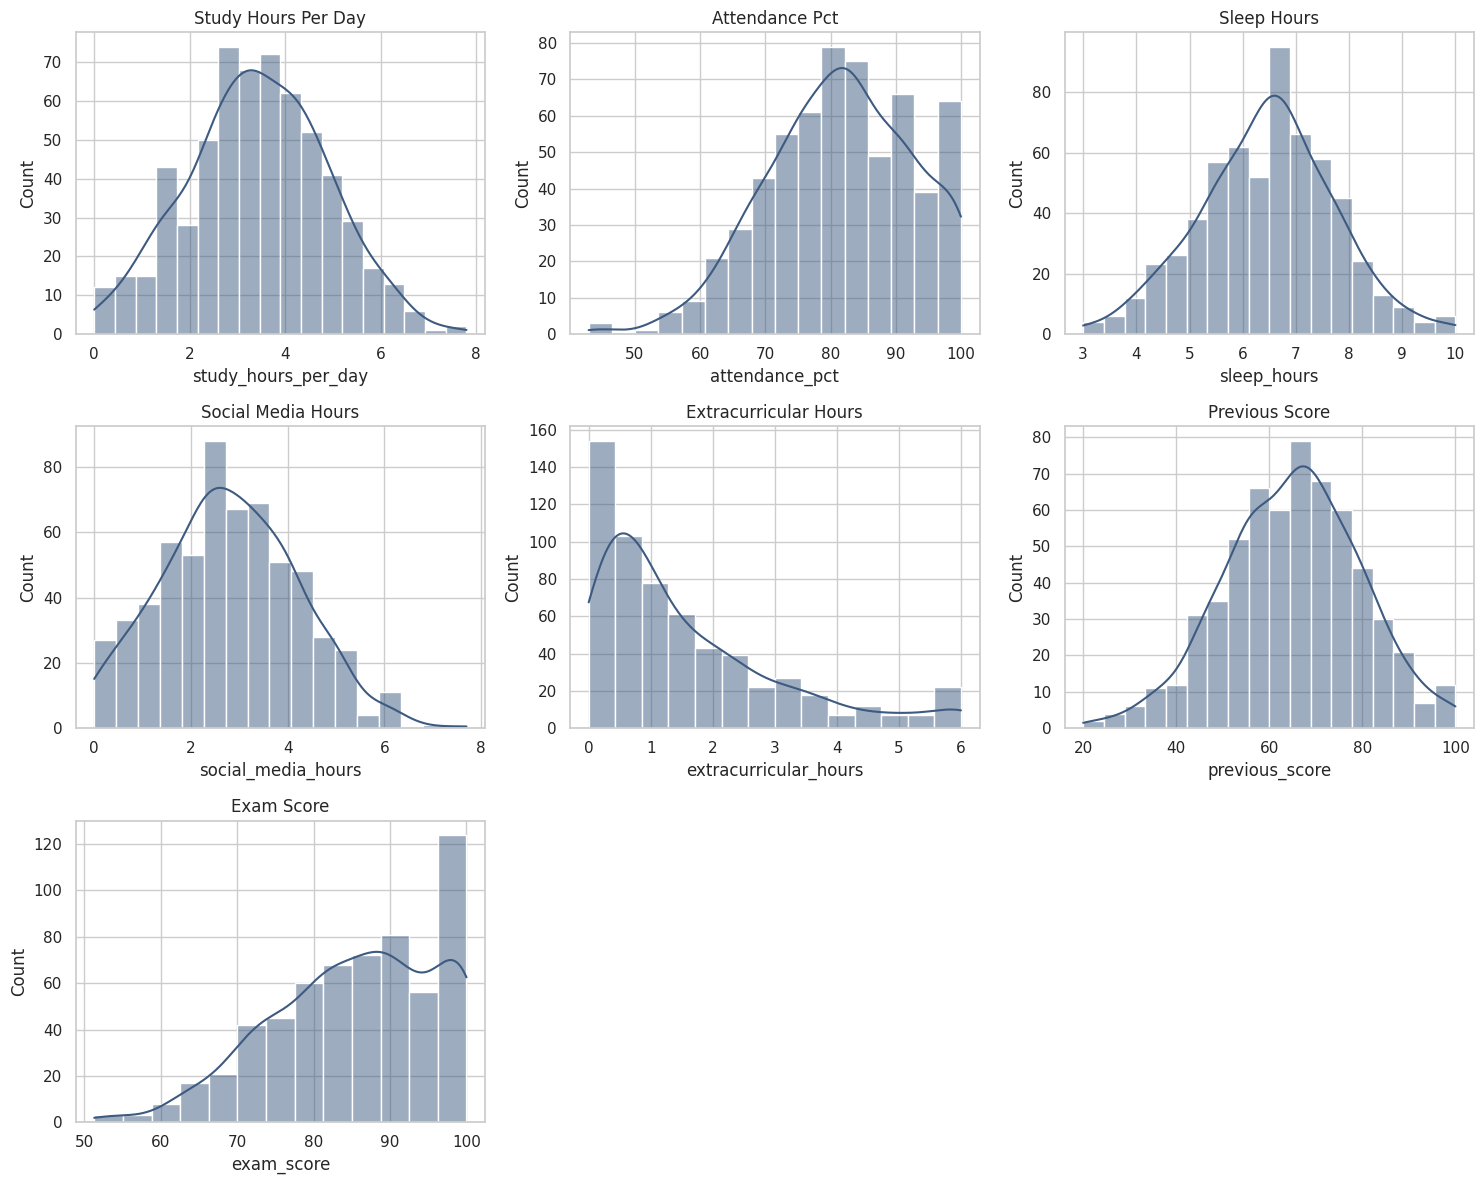

In [4]:
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()
for i, col in enumerate(numeric_cols):
    sns.histplot(df[col], kde=True, ax=axes[i], color="#3d5a80")
    axes[i].set_title(col.replace("_"," ").title())
for j in range(len(numeric_cols), len(axes)):
    fig.delaxes(axes[j])
plt.tight_layout()
plt.show()

## 5. Correlation Analysis

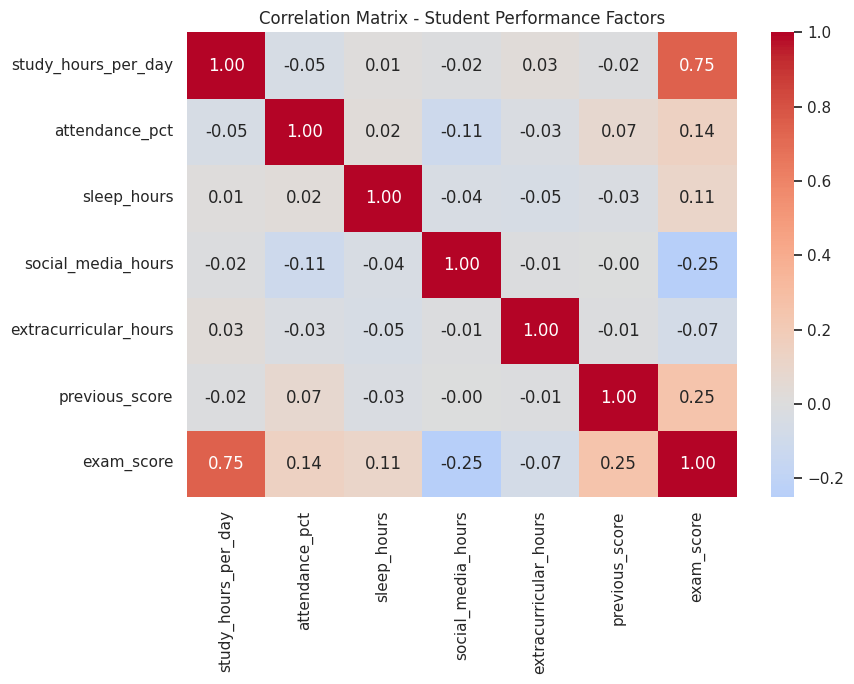

study_hours_per_day      0.748506
previous_score           0.254827
social_media_hours      -0.251109
attendance_pct           0.142550
sleep_hours              0.105820
extracurricular_hours   -0.074597
Name: exam_score, dtype: float64

In [5]:
corr = df[numeric_cols].corr()
plt.figure(figsize=(9,7))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f", center=0)
plt.title("Correlation Matrix - Student Performance Factors")
plt.tight_layout()
plt.show()

exam_corr = corr["exam_score"].drop("exam_score").sort_values(key=abs, ascending=False)
exam_corr

## 6. Key Influencing Factors — Scatter Plots

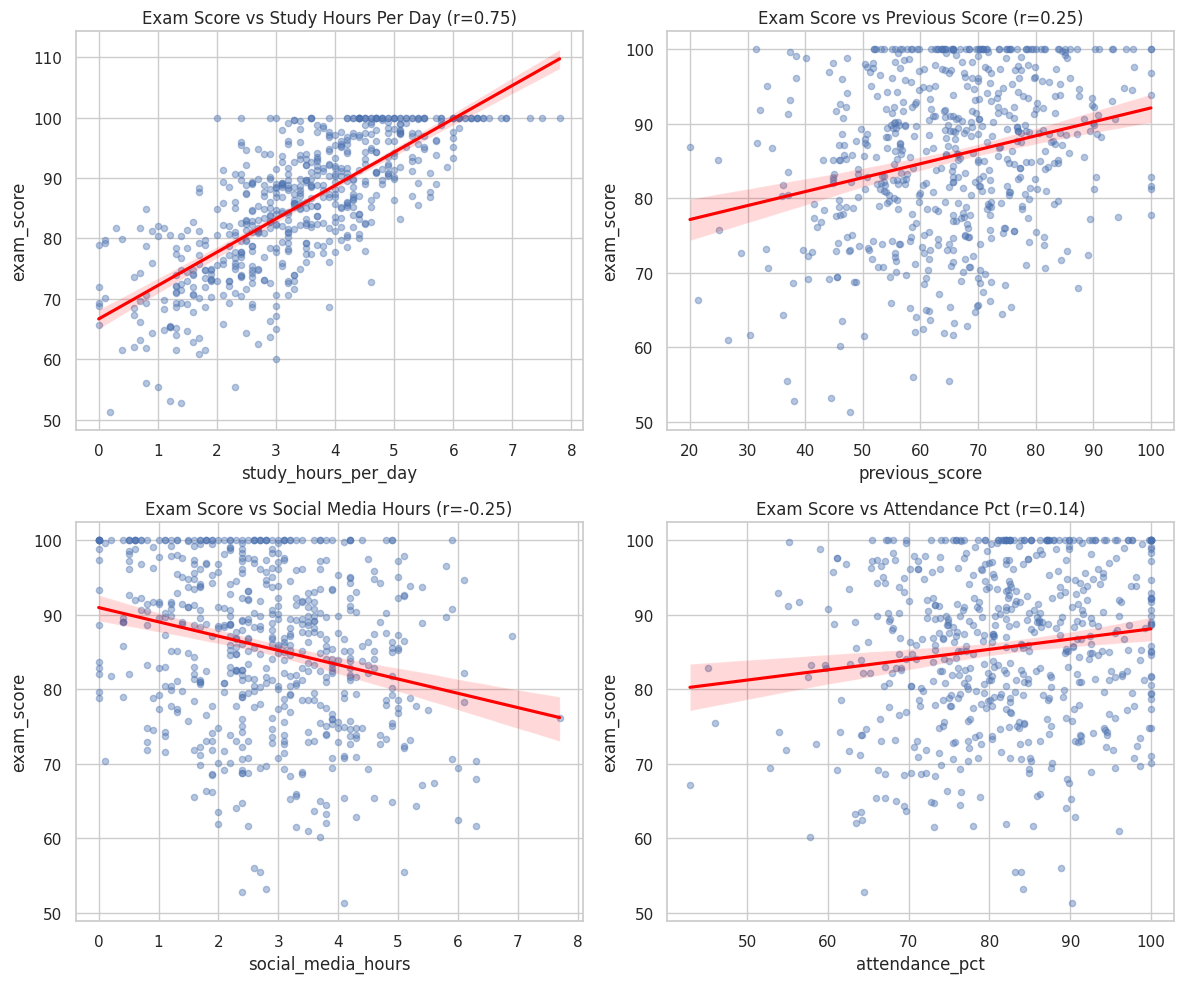

In [6]:
top_factors = exam_corr.index[:4]
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()
for i, factor in enumerate(top_factors):
    sns.regplot(data=df, x=factor, y="exam_score", ax=axes[i],
                scatter_kws={"alpha":0.4,"s":20}, line_kws={"color":"red"})
    axes[i].set_title(f"Exam Score vs {factor.replace('_',' ').title()} (r={exam_corr[factor]:.2f})")
plt.tight_layout()
plt.show()

## 7. Categorical Breakdown

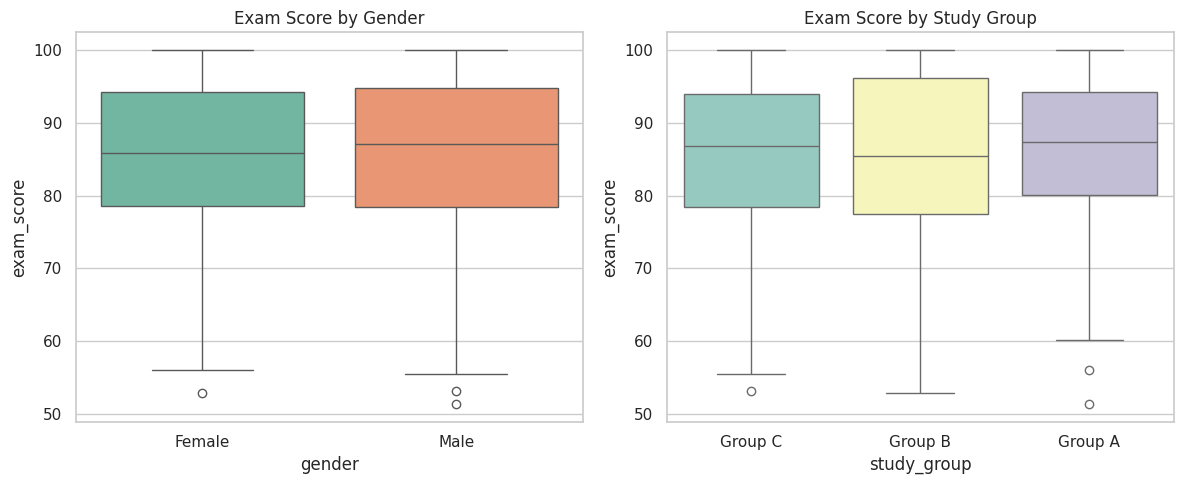

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.boxplot(data=df, x="gender", y="exam_score", ax=axes[0], hue="gender", legend=False, palette="Set2")
axes[0].set_title("Exam Score by Gender")
sns.boxplot(data=df, x="study_group", y="exam_score", ax=axes[1], hue="study_group", legend=False, palette="Set3")
axes[1].set_title("Exam Score by Study Group")
plt.tight_layout()
plt.show()

## 8. Key Findings

1. **Study hours per day** is by far the strongest predictor of exam score (r ≈ 0.75).
2. **Previous score** and **social media hours** show moderate correlations (positive and negative respectively).
3. **Attendance** and **sleep** have weaker but still positive associations.
4. **Gender** and **study group** show little to no meaningful difference in outcomes in this dataset.
5. Correlation does not imply causation — these are associations worth validating with a controlled study or predictive model (see the companion `predictive-modeling-project`).

Full write-up: see `outputs/EDA_REPORT.md`.